# Aula 9 — Laboratório: comparação honesta de todos os modelos supervisionados

**Aprendizado de Máquina (PEPAPRM)** · IFSP Câmpus Presidente Epitácio

Objetivo: colocar **todos os modelos supervisionados vistos** sob o mesmo protocolo de validação cruzada, na regressão (aluguéis) e na classificação (empréstimos); ajustar os hiperparâmetros de todos com justiça; medir o desempenho honesto com **validação cruzada aninhada**; e fechar a escolha com o **protocolo completo**.

> Deixe `alugueis_tratado.csv` na mesma pasta deste notebook. A seção 4 treina centenas de modelos e leva cerca de 1 minuto.

In [1]:
import warnings

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, recall_score
from sklearn.model_selection import (GridSearchCV, KFold, RepeatedStratifiedKFold,
                                     StratifiedKFold, cross_val_score,
                                     cross_validate, train_test_split)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler
from sklearn.svm import SVC, SVR
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

warnings.filterwarnings("ignore")
SEMENTE = 42
pd.set_option("display.width", 110)

warnings.filterwarnings("ignore")
SEMENTE = 42
pd.set_option("display.width", 110)

As funções abaixo são as mesmas das aulas anteriores: geram o conjunto de solicitações de empréstimo (com ausentes, uma coluna categórica e outliers) e montam o pré-processamento dentro de um `Pipeline`.

In [2]:
def gerar_dados_emprestimo(n=450, semente=42):
    """Mesmo dataset das aulas de preparacao de dados: solicitacoes de
    emprestimo, com valores ausentes, uma coluna categorica e outliers."""
    rng = np.random.default_rng(semente)

    idade = rng.normal(38, 12, n).clip(18, 75).round().astype(float)
    score_credito = rng.normal(650, 80, n).clip(300, 850).round().astype(float)
    tempo_emprego = rng.normal(7, 5, n).clip(0, 35).round().astype(float)

    renda = rng.lognormal(mean=8.15, sigma=0.45, size=n)
    idx_outlier = rng.choice(n, size=5, replace=False)
    renda[idx_outlier] *= rng.uniform(6, 10, size=5)
    renda = renda.round(2)

    cidades = np.array(["SP", "RJ", "MG", "Outra"])
    cidade = rng.choice(cidades, size=n, p=[0.42, 0.23, 0.15, 0.20])

    renda_c = np.clip(renda, None, np.percentile(renda, 95))
    z = (
        0.05 * (score_credito - 650)
        + 0.0008 * (renda_c - renda_c.mean())
        + 0.12 * (tempo_emprego - 7)
        + rng.normal(0, 0.35, n)
    )
    prob_aprovado = 1 / (1 + np.exp(-z))
    aprovado = (rng.uniform(0, 1, n) < prob_aprovado).astype(int)

    df = pd.DataFrame({
        "idade": idade,
        "renda": renda,
        "tempo_emprego": tempo_emprego,
        "score_credito": score_credito,
        "cidade": cidade,
        "aprovado": aprovado,
    })

    mask_idade = rng.uniform(0, 1, n) < 0.08
    mask_renda = rng.uniform(0, 1, n) < 0.10
    mask_cidade = rng.uniform(0, 1, n) < 0.06
    df.loc[mask_idade, "idade"] = np.nan
    df.loc[mask_renda, "renda"] = np.nan
    df.loc[mask_cidade, "cidade"] = None
    return df


COL_NUM = ["idade", "renda", "tempo_emprego", "score_credito"]
COL_CAT = ["cidade"]


def montar_preprocessador():
    return ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("esc", StandardScaler())]), COL_NUM),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("oh", OneHotEncoder(handle_unknown="ignore"))]), COL_CAT),
    ])


def com_prep(modelo):
    return Pipeline([("prep", montar_preprocessador()), ("modelo", modelo)])

## 1. Regressão: todos os modelos, mesmas dobras

Cada modelo passa pelas **mesmas 5 dobras** (`KFold` com `shuffle=True`), e `cross_validate` calcula MAE, RMSE e R² de uma vez. Repare no pré-processamento de cada um: k-NN e SVR recebem `StandardScaler` (usam distância); a polinomial é `PolynomialFeatures` + `LinearRegression`; a linear simples usa só a área. Incluímos também o **SVR com o `C` padrão (C=1)**.

alugueis: 1000 anuncios, 3 atributos, alvo = valor_aluguel


                           MAE     RMSE  RMSE_desvio     R2
modelo                                                     
Polinomial (grau 2)    117.563  146.219        5.173  0.900
SVR (rbf, C=1000)      115.487  146.226        3.100  0.900
k-NN (k=15)            123.387  155.703        4.526  0.887
Linear multipla        126.143  156.697        3.915  0.886
Arvore (max_depth=5)   148.278  188.662        4.596  0.834
Linear simples (area)  177.605  221.403        7.526  0.771
SVR (rbf, C=1 padrao)  304.093  393.569       16.892  0.281
Baseline (media)       375.594  465.351       16.630 -0.006
-> o MESMO SVR vai do penultimo ao primeiro lugar so trocando C: comparar
   modelos com hiperparametros 'de fabrica' pode ser injusto (Bloco 4).


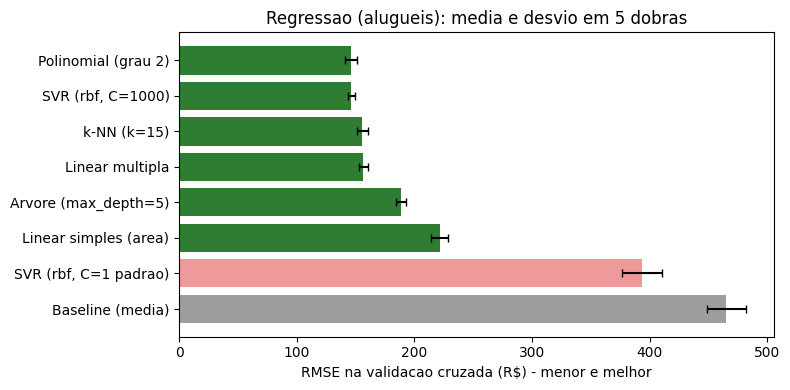

In [3]:
alugueis = pd.read_csv("alugueis_tratado.csv")
Xa = alugueis[["area_m2", "quartos", "distancia_km"]]
ya = alugueis["valor_aluguel"]
print(f"alugueis: {Xa.shape[0]} anuncios, {Xa.shape[1]} atributos, alvo = valor_aluguel")

# Regressao linear SIMPLES usa so area_m2: um ColumnTransformer escolhe a coluna
so_area = ColumnTransformer([("area", "passthrough", ["area_m2"])])

modelos_reg = {
    "Baseline (media)": DummyRegressor(strategy="mean"),
    "Linear simples (area)": make_pipeline(so_area, LinearRegression()),
    "Linear multipla": LinearRegression(),
    "Polinomial (grau 2)": make_pipeline(PolynomialFeatures(degree=2, include_bias=False),
                                         LinearRegression()),
    "k-NN (k=15)": make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=15)),
    "Arvore (max_depth=5)": DecisionTreeRegressor(max_depth=5, random_state=SEMENTE),
    "SVR (rbf, C=1 padrao)": make_pipeline(StandardScaler(), SVR(kernel="rbf")),
    "SVR (rbf, C=1000)": make_pipeline(StandardScaler(),
                                       SVR(kernel="rbf", C=1000, epsilon=50)),
}

dobras_reg = KFold(n_splits=5, shuffle=True, random_state=SEMENTE)
metricas_reg = {"MAE": "neg_mean_absolute_error",
                "RMSE": "neg_root_mean_squared_error",
                "R2": "r2"}

linhas = []
notas_rmse = {}
for nome, modelo in modelos_reg.items():
    res = cross_validate(modelo, Xa, ya, cv=dobras_reg, scoring=metricas_reg)
    mae = -res["test_MAE"]            # o scikit-learn devolve o erro NEGATIVO
    rmse = -res["test_RMSE"]
    r2 = res["test_R2"]
    notas_rmse[nome] = rmse
    linhas.append({"modelo": nome, "MAE": mae.mean(), "RMSE": rmse.mean(),
                   "RMSE_desvio": rmse.std(), "R2": r2.mean()})
tab_reg = pd.DataFrame(linhas).set_index("modelo").sort_values("RMSE")
print(tab_reg.round(3))
print("-> o MESMO SVR vai do penultimo ao primeiro lugar so trocando C: comparar")
print("   modelos com hiperparametros 'de fabrica' pode ser injusto (Bloco 4).")

fig, ax = plt.subplots(figsize=(8, 4))
ordem = tab_reg.index[::-1]
ax.barh(ordem, tab_reg.loc[ordem, "RMSE"], xerr=tab_reg.loc[ordem, "RMSE_desvio"],
        color=["#9e9e9e" if n.startswith("Baseline") else
               "#ef9a9a" if "padrao" in n else "#2e7d32" for n in ordem],
        capsize=3)
ax.set_xlabel("RMSE na validacao cruzada (R$) - menor e melhor")
ax.set_title("Regressao (alugueis): media e desvio em 5 dobras")
plt.tight_layout()
plt.show()


**Leitura.** Polinomial grau 2 e SVR (C=1000) empatam no topo: a diferença é muito menor que o desvio. k-NN e linear múltipla ficam cerca de R$ 10 atrás. A linear simples mostra que **atributos importam mais que o algoritmo**. E o **mesmo SVR** vai do penúltimo ao primeiro lugar só trocando `C` — comparar modelos com hiperparâmetros "de fábrica" pode ser injusto.

## 2. Duas armadilhas: o sinal negativo e as dobras sem embaralhar

1. O scikit-learn sempre **maximiza** a nota, então MAE e RMSE voltam com sinal trocado (`neg_...`).
2. Se o arquivo estiver **ordenado pelo alvo**, `KFold` sem `shuffle` cria dobras com faixas de preço que o treino não viu.

In [4]:
neg = cross_val_score(LinearRegression(), Xa, ya, cv=dobras_reg,
                      scoring="neg_mean_absolute_error")
print("scoring='neg_mean_absolute_error' devolve:", neg.round(1))
print("-> numeros NEGATIVOS: o scikit-learn sempre MAXIMIZA a nota, entao o erro")
print("   vem com sinal trocado. Troque o sinal antes de reportar: MAE =", round(-neg.mean(), 1))

# Mesmos dados, mas ORDENADOS pelo alvo (como um arquivo exportado 'por preco')
ordenado = alugueis.sort_values("valor_aluguel").reset_index(drop=True)
Xo = ordenado[["area_m2", "quartos", "distancia_km"]]
yo = ordenado["valor_aluguel"]
sem_emb = cross_val_score(LinearRegression(), Xo, yo, cv=KFold(n_splits=5), scoring="r2")
com_emb = cross_val_score(LinearRegression(), Xo, yo,
                          cv=KFold(n_splits=5, shuffle=True, random_state=SEMENTE),
                          scoring="r2")
print()
print("arquivo ordenado por valor_aluguel, regressao linear multipla:")
print("  KFold SEM shuffle -> R2 por dobra:", sem_emb.round(2), " media:", round(sem_emb.mean(), 3))
print("  KFold COM shuffle -> R2 por dobra:", com_emb.round(2), " media:", round(com_emb.mean(), 3))


scoring='neg_mean_absolute_error' devolve: [-117.3 -128.  -127.5 -123.1 -134.8]
-> numeros NEGATIVOS: o scikit-learn sempre MAXIMIZA a nota, entao o erro
   vem com sinal trocado. Troque o sinal antes de reportar: MAE = 126.1

arquivo ordenado por valor_aluguel, regressao linear multipla:
  KFold SEM shuffle -> R2 por dobra: [-1.15 -1.01 -3.77 -3.54 -0.25]  media: -1.944
  KFold COM shuffle -> R2 por dobra: [0.89 0.91 0.87 0.87 0.88]  media: 0.886


Sem embaralhar, cada dobra pede ao modelo que **extrapole** para uma faixa de aluguel ausente do treino — e o R² negativo diz que prever a média seria melhor. Use sempre `shuffle=True` com `random_state` fixo. (Exceção: dados temporais, em que se usa `TimeSeriesSplit`.)

## 3. Classificação: seis famílias + baseline, validação repetida

`RepeatedStratifiedKFold` com 5 dobras × 5 repetições = **25 avaliações por modelo**, todas com as mesmas divisões. Isso permite contar em quantas divisões cada modelo foi o melhor (comparação pareada).

                              acuracia  desvio     F1  recall
modelo                                                       
SVM (rbf)                        0.852   0.037  0.848   0.858
Regressao logistica              0.851   0.040  0.846   0.849
Random Forest (200 arvores)      0.849   0.038  0.845   0.850
Naive Bayes                      0.825   0.044  0.819   0.828
Arvore (max_depth=4)             0.824   0.033  0.813   0.798
k-NN (k=5)                       0.798   0.035  0.790   0.791
Baseline (classe mais comum)     0.520   0.004  0.000   0.000

em quantas das 25 divisoes cada modelo foi o melhor (empates contam para todos):
SVM (rbf)                      12
Regressao logistica             9
Random Forest (200 arvores)     6
k-NN (k=5)                      2
Arvore (max_depth=4)            1
Naive Bayes                     1


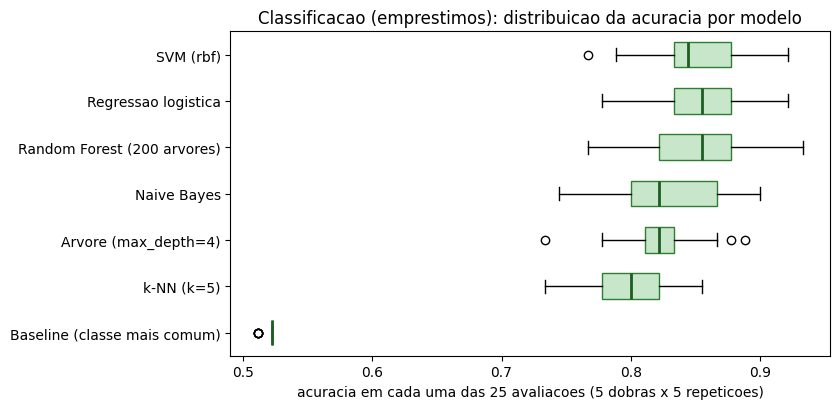

In [5]:
df = gerar_dados_emprestimo(n=450, semente=SEMENTE)
X = df.drop(columns="aprovado")
y = df["aprovado"]

modelos_clf = {
    "Baseline (classe mais comum)": DummyClassifier(strategy="most_frequent"),
    "k-NN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Regressao logistica": LogisticRegression(max_iter=1000),
    "Arvore (max_depth=4)": DecisionTreeClassifier(max_depth=4, random_state=SEMENTE),
    "Random Forest (200 arvores)": RandomForestClassifier(n_estimators=200, random_state=SEMENTE),
    "Naive Bayes": GaussianNB(),
    "SVM (rbf)": SVC(kernel="rbf"),
}

# 5 dobras x 5 repeticoes = 25 avaliacoes por modelo, TODAS com as mesmas divisoes
dobras_rep = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=SEMENTE)
linhas = []
notas_acc = {}
for nome, modelo in modelos_clf.items():
    res = cross_validate(com_prep(modelo), X, y, cv=dobras_rep,
                         scoring=["accuracy", "f1", "recall"])
    notas_acc[nome] = res["test_accuracy"]
    linhas.append({"modelo": nome,
                   "acuracia": res["test_accuracy"].mean(),
                   "desvio": res["test_accuracy"].std(),
                   "F1": res["test_f1"].mean(),
                   "recall": res["test_recall"].mean()})
tab_clf = pd.DataFrame(linhas).set_index("modelo").sort_values("acuracia", ascending=False)
print(tab_clf.round(3))

# Quantas das 25 avaliacoes cada modelo venceu (mesmas divisoes -> comparacao pareada)
matriz = pd.DataFrame(notas_acc).drop(columns="Baseline (classe mais comum)")
vitorias = matriz.eq(matriz.max(axis=1), axis=0).sum()
print("\nem quantas das 25 divisoes cada modelo foi o melhor (empates contam para todos):")
print(vitorias.sort_values(ascending=False).to_string())

fig, ax = plt.subplots(figsize=(8.5, 4.2))
ordem = list(tab_clf.index[::-1])
ax.boxplot([notas_acc[n] for n in ordem], vert=False, widths=0.55,
           patch_artist=True, boxprops=dict(facecolor="#c8e6c9", color="#2e7d32"),
           medianprops=dict(color="#1b5e20", linewidth=2))
ax.set_yticks(range(1, len(ordem) + 1))
ax.set_yticklabels(ordem)
ax.set_xlabel("acuracia em cada uma das 25 avaliacoes (5 dobras x 5 repeticoes)")
ax.set_title("Classificacao (emprestimos): distribuicao da acuracia por modelo")
plt.tight_layout()
plt.show()


**Leitura.** SVM, regressão logística e Random Forest estão empatados (diferenças ≤ 0,003 contra desvio ≈ 0,04). O k-NN ficou por último — **mas com k=5**, escolhido sem critério. Antes de concluir algo sobre o k-NN, todos os modelos precisam ter seus hiperparâmetros escolhidos.

## 4. Ajuste justo e validação cruzada aninhada

Cada modelo ganha uma grade de hiperparâmetros e um `GridSearchCV`. Comparamos duas notas:

- **`best_score_`**: a nota da melhor configuração, medida nas **mesmas dobras** que a escolheram → otimista;
- **validação aninhada**: `cross_val_score(GridSearchCV(...), X, y, cv=externa)` → a busca é refeita dentro de cada dobra externa e a nota vem de dados que não participaram da escolha.

                                       melhor_config  best_score_  aninhada  aninhada_desvio  otimismo
modelo                                                                                                
SVM (rbf)                          C=100, gamma=0.01        0.876     0.864            0.036     0.011
Random Forest        max_depth=3, min_samples_leaf=5        0.860     0.853            0.029     0.007
k-NN                                 n_neighbors=125        0.853     0.847            0.041     0.007
Regressao logistica                            C=0.1        0.858     0.840            0.032     0.018
Arvore                                   max_depth=3        0.836     0.829            0.033     0.007

best_score_ = nota da MELHOR configuracao nas mesmas dobras usadas para escolhe-la
aninhada    = nota de quem escolhe e depois e avaliado em dobras que nao viu


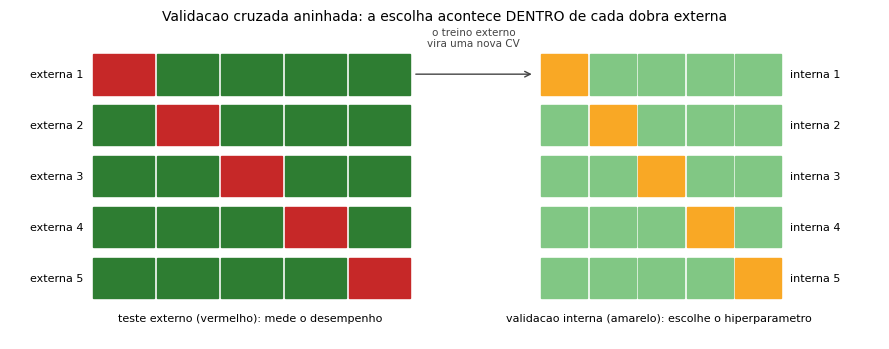

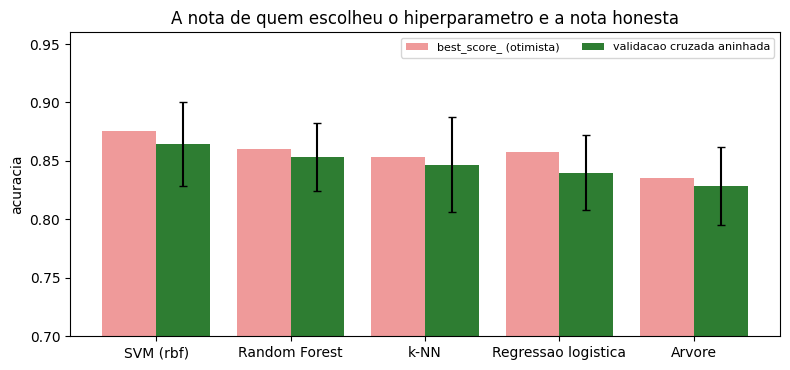

In [6]:
grades = {
    "k-NN": (KNeighborsClassifier(),
             {"modelo__n_neighbors": [5, 15, 25, 45, 75, 125]}),
    "Arvore": (DecisionTreeClassifier(random_state=SEMENTE),
               {"modelo__max_depth": [2, 3, 4, 6, 8, None]}),
    "Random Forest": (RandomForestClassifier(n_estimators=200, random_state=SEMENTE),
                      {"modelo__max_depth": [3, 5, None],
                       "modelo__min_samples_leaf": [1, 5, 10]}),
    "Regressao logistica": (LogisticRegression(max_iter=1000),
                            {"modelo__C": [0.01, 0.1, 1, 10, 100]}),
    "SVM (rbf)": (SVC(kernel="rbf"),
                  {"modelo__C": [0.1, 1, 10, 100],
                   "modelo__gamma": ["scale", 0.01, 0.1]}),
}

interna = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMENTE)
externa = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMENTE + 1)

linhas = []
for nome, (modelo, grade) in grades.items():
    busca = GridSearchCV(com_prep(modelo), grade, cv=interna)
    busca.fit(X, y)
    # validacao cruzada ANINHADA: a busca inteira e refeita dentro de cada dobra externa
    aninhada = cross_val_score(GridSearchCV(com_prep(modelo), grade, cv=interna),
                               X, y, cv=externa)
    linhas.append({"modelo": nome,
                   "melhor_config": ", ".join(f"{k.split('__')[1]}={v}"
                                              for k, v in busca.best_params_.items()),
                   "best_score_": busca.best_score_,
                   "aninhada": aninhada.mean(),
                   "aninhada_desvio": aninhada.std(),
                   "otimismo": busca.best_score_ - aninhada.mean()})
tab_ajuste = pd.DataFrame(linhas).set_index("modelo").sort_values("aninhada", ascending=False)
print(tab_ajuste.round(3).to_string())
print("\nbest_score_ = nota da MELHOR configuracao nas mesmas dobras usadas para escolhe-la")
print("aninhada    = nota de quem escolhe e depois e avaliado em dobras que nao viu")

# Esquema da validacao cruzada aninhada (so desenho, nenhum modelo e treinado aqui)
from matplotlib.patches import Rectangle
fig, ax = plt.subplots(figsize=(9, 3.6))
for i in range(5):                       # 5 dobras EXTERNAS
    for j in range(5):
        cor = "#c62828" if j == i else "#2e7d32"
        ax.add_patch(Rectangle((j, 4 - i), 0.95, 0.8, color=cor))
    ax.text(-0.15, 4 - i + 0.4, f"externa {i + 1}", ha="right", va="center", fontsize=8)
# detalhe da dobra externa 1: o treino externo e dividido de novo (dobras INTERNAS)
for i in range(5):                       # 5 dobras INTERNAS, so com o treino externo
    for j in range(5):
        cor = "#f9a825" if j == i else "#81c784"
        ax.add_patch(Rectangle((7 + j * 0.76, 4 - i), 0.72, 0.8, color=cor))
    ax.text(10.9, 4 - i + 0.4, f"interna {i + 1}", ha="left", va="center", fontsize=8)
ax.annotate("", xy=(6.9, 4.4), xytext=(5.0, 4.4),
            arrowprops=dict(arrowstyle="->", color="#444444"))
ax.text(5.95, 4.95, "o treino externo\nvira uma nova CV", ha="center", fontsize=7.5, color="#444444")
ax.text(2.45, -0.45, "teste externo (vermelho): mede o desempenho", ha="center", fontsize=8)
ax.text(8.85, -0.45, "validacao interna (amarelo): escolhe o hiperparametro",
        ha="center", fontsize=8)
ax.set_xlim(-1.3, 12.3)
ax.set_ylim(-0.8, 5.3)
ax.axis("off")
ax.set_title("Validacao cruzada aninhada: a escolha acontece DENTRO de cada dobra externa",
             fontsize=10)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 3.8))
pos = np.arange(len(tab_ajuste))
ax.bar(pos - 0.2, tab_ajuste["best_score_"], 0.4, color="#ef9a9a", label="best_score_ (otimista)")
ax.bar(pos + 0.2, tab_ajuste["aninhada"], 0.4, color="#2e7d32",
       yerr=tab_ajuste["aninhada_desvio"], capsize=3, label="validacao cruzada aninhada")
ax.set_xticks(pos)
ax.set_xticklabels(tab_ajuste.index, rotation=0)
ax.set_ylim(0.70, 0.96)
ax.set_ylabel("acuracia")
ax.set_title("A nota de quem escolheu o hiperparametro e a nota honesta")
ax.legend(loc="upper right", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()


**Leitura.** O k-NN subiu de 0,798 (k=5) para ≈ 0,847 (k=125) e alcançou o grupo da frente. O `best_score_` fica **sempre** acima da nota aninhada; aqui o otimismo é pequeno porque as grades são pequenas, mas cresce com grades grandes e poucos dados. **O número a reportar é o da validação aninhada.**

## 5. O protocolo completo: escolher no treino, conferir no teste uma vez

1. separe o teste no início; 2. `GridSearchCV` **só no treino** para cada família; 3. escolha pela CV do treino; 4. o `best_estimator_` já vem re-treinado com todo o treino; 5. meça no teste **uma única vez**.

In [7]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25,
                                          random_state=SEMENTE, stratify=y)
print(f"treino: {len(X_tr)} solicitacoes | teste (guardado): {len(X_te)}")

candidatos = {}
for nome, (modelo, grade) in grades.items():
    busca = GridSearchCV(com_prep(modelo), grade, cv=interna)
    busca.fit(X_tr, y_tr)                      # a validacao cruzada acontece SO no treino
    candidatos[nome] = busca
    print(f"  {nome:<22} CV no treino = {busca.best_score_:.3f}   ({busca.best_params_})")
nb_cv = cross_val_score(com_prep(GaussianNB()), X_tr, y_tr, cv=interna).mean()
print(f"  {'Naive Bayes':<22} CV no treino = {nb_cv:.3f}   (sem hiperparametro na grade)")

escolhido = max(candidatos, key=lambda n: candidatos[n].best_score_)
modelo_final = candidatos[escolhido].best_estimator_   # ja re-treinado com TODO o treino
y_prev = modelo_final.predict(X_te)
print(f"\nescolhido pela CV do treino: {escolhido}")
print(f"TESTE (usado uma unica vez): acuracia = {accuracy_score(y_te, y_prev):.3f} | "
      f"F1 = {f1_score(y_te, y_prev):.3f} | recall = {recall_score(y_te, y_prev):.3f}")


treino: 337 solicitacoes | teste (guardado): 113


  k-NN                   CV no treino = 0.852   ({'modelo__n_neighbors': 75})


  Arvore                 CV no treino = 0.825   ({'modelo__max_depth': 4})


  Random Forest          CV no treino = 0.852   ({'modelo__max_depth': 3, 'modelo__min_samples_leaf': 1})


  Regressao logistica    CV no treino = 0.846   ({'modelo__C': 10})


  SVM (rbf)              CV no treino = 0.867   ({'modelo__C': 10, 'modelo__gamma': 0.01})
  Naive Bayes            CV no treino = 0.816   (sem hiperparametro na grade)

escolhido pela CV do treino: SVM (rbf)
TESTE (usado uma unica vez): acuracia = 0.867 | F1 = 0.870 | recall = 0.926


Se o teste decepcionar, **não** volte para trocar de modelo e testar de novo no mesmo teste: na segunda tentativa ele já virou validação.

## 6. Parcimônia: quando há empate, o custo decide

Com desempenho empatado, olhe o custo de treino, o número de hiperparâmetros e — em crédito, principalmente — a facilidade de **explicar** a decisão ao cliente.

In [8]:
for nome, modelo in [("Regressao logistica", LogisticRegression(max_iter=1000)),
                     ("SVM (rbf)", SVC(kernel="rbf")),
                     ("Random Forest", RandomForestClassifier(n_estimators=200,
                                                              random_state=SEMENTE))]:
    res = cross_validate(com_prep(modelo), X, y, cv=dobras_rep)
    print(f"  {nome:<20} acuracia = {res['test_score'].mean():.3f}   "
          f"tempo medio de treino por dobra = {1000 * res['fit_time'].mean():6.1f} ms")
print("-> com acuracias empatadas, o modelo mais simples, rapido e explicavel")
print("   (aqui, a regressao logistica) costuma ser a melhor escolha pratica.")


  Regressao logistica  acuracia = 0.851   tempo medio de treino por dobra =   12.2 ms


  SVM (rbf)            acuracia = 0.852   tempo medio de treino por dobra =    9.5 ms


  Random Forest        acuracia = 0.849   tempo medio de treino por dobra =  192.8 ms
-> com acuracias empatadas, o modelo mais simples, rapido e explicavel
   (aqui, a regressao logistica) costuma ser a melhor escolha pratica.


## O que guardar

- Um protocolo único — mesmas dobras, `Pipeline`, baseline, média ± desvio — vale para regressão e classificação.
- Métricas de erro voltam negativas (`neg_`): troque o sinal.
- Arquivo ordenado + dobras sem embaralhar = R² negativo.
- Comparar modelos "de fábrica" é injusto; ajuste todos com o mesmo procedimento, dentro do treino.
- `best_score_` é otimista; a validação aninhada separa quem escolhe de quem mede.
- O teste é usado uma única vez; empates se decidem por parcimônia.